# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c
dt=0.01

    # Het updaten van de positie, eventueel met zwaartekracht
def update_position(self):
    self.r += self.v*dt #+ 1/2 * a * dt**2  
              
    # Harde wand
def boxcollision(self):
    if abs(self.r[0]) + self.R > Box_length: 
        self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
        self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
    if abs(self.r[1]) + self.R > Box_length: 
        self.v[1] = -self.v[1]     
        self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [4]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
De laatste regel in de code voegt grotere deetjes toe, Dit stellen de pollen in het water voor. Ze hebben een grotere massa dan de watermoleculen en hun snelheid wordt bepaald door de botsingen met de watermoleculen.

Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
#your code/answer
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



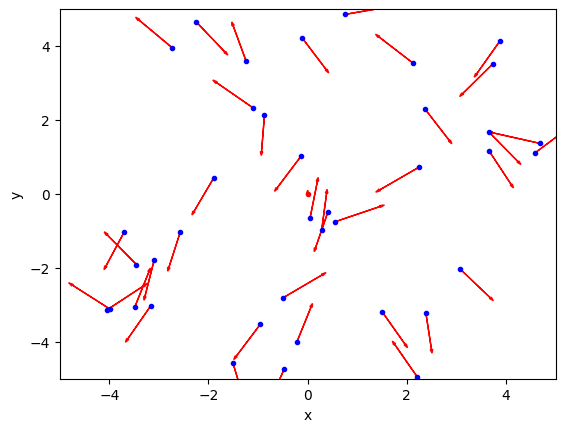

In [5]:
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1],  particle_object.v[0],particle_object.v[1], head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Dit geeft een lijn die aangeeft waar het puntje was begonnen
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
Er wordt eerst een snelheid in de x-richting bepaald door een willekrig getal tussen -v_0 en v_0, De y-snelheid wordt op de x-snaelheid afgestemd zodat de totale snelheid gelijk is aan v_0, er wordt hier gebruik gemaakt van het feit dat vy = (v_0^2 - vx^2) 
```

```{solution} ex-brownian-2
#your code/answer
```

We gaan nu de functies van de simulatie weer aanroepen:

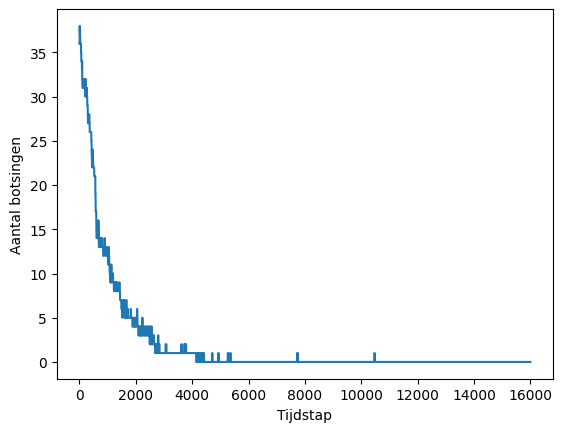

In [6]:
# Het bepalen of er een botsing plaats vindt
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 

def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return 
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    counter = 0
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                counter += 1
    return counter
#your code/answer
collision_count = []

for i in range(400):
    for p in particles:
        update_position(p)    # Update positie        
        n_collisions=handle_collisions(particles)
        collision_count.append(n_collisions)

plt.figure()
plt.plot(collision_count)
plt.xlabel('Tijdstap')
plt.ylabel('Aantal botsingen')
plt.show()



In [7]:
print(dir(ParticleClass))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__']


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

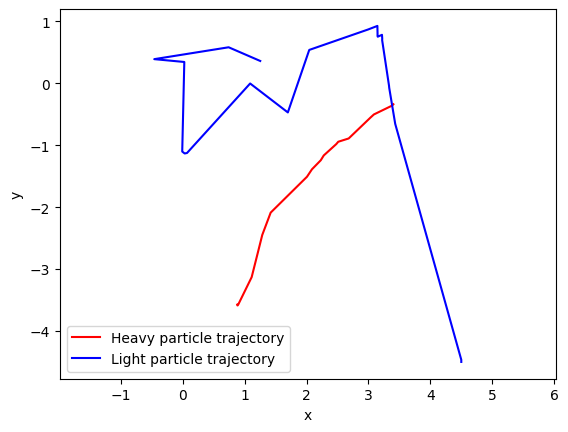

In [8]:
# tracken van het zware deeltje
track_x = []
track_y = []
light_x = []
light_y = []
# aantal deeltjes
N = len(particles)

# beginpositie opslaan
track_x.append(particles[N-1].r[0])
track_y.append(particles[N-1].r[1])

for i in range(400):
    for p in particles:
        update_position(p)     # Update positie
        boxcollision(p)        # Wandbotsing per deeltje

    # onderlinge botsingen
    handle_collisions(particles)

    # positie zware deeltje opslaan
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    light_x.append(particles[0].r[0])
    light_y.append(particles[0].r[1])

# plot traject
plt.figure()
plt.plot(track_x, track_y, 'r', label='Heavy particle trajectory')
plt.plot(light_x, light_y, 'b', label='Light particle trajectory')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()


```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
#your code/answer
```3, Het zwaare deeltje heeft een kortere beweging, terwijl beide deeltjes veel kronkelingen hebben.
    4, De deeltjes raken elkaar nooit.

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

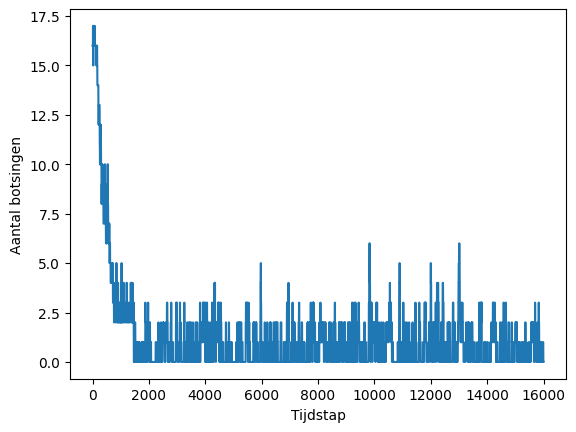

In [9]:
# Het bepalen of er een botsing plaats vindt
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 

def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return 
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    counter = 0
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
                counter += 1
    return counter
#your code/answer
collision_count = []

for i in range(400):
    for p in particles:
        update_position(p)    # Update positie        
        boxcollision(p)         # Wandbotsing werkt per deeltje

        n_collisions=handle_collisions(particles)
        collision_count.append(n_collisions)

plt.figure()
plt.plot(collision_count)
plt.xlabel('Tijdstap')
plt.ylabel('Aantal botsingen')
plt.show()




```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


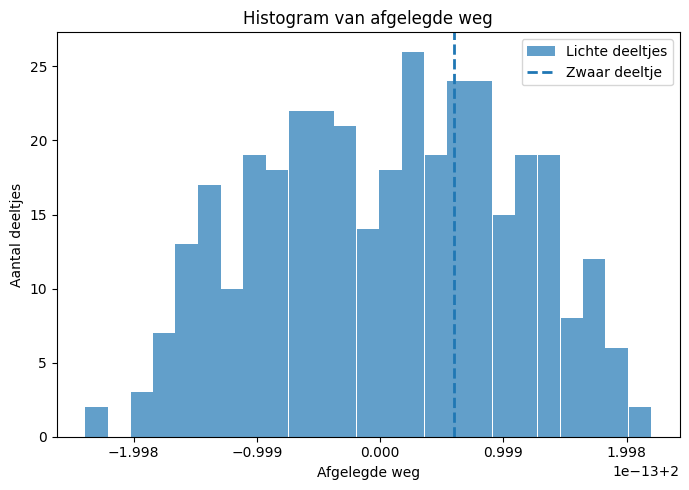

Afgelegde weg zwaar deeltje: 2.000


In [10]:
particles = []
Box_length= Box_length_0*9

def boxcollision2(self):
    if abs(self.r[0]) + self.R > Box_length: 
        self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
        self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
    if abs(self.r[1]) + self.R > Box_length: 
        self.v[1] = -self.v[1]     
        self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 

vx = np.random.uniform(-v_0,v_0)
vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)
pos = Box_length*np.random.uniform(-1,1,2)
for i in range(360):
    vx_light = np.random.uniform(-v_0,v_0)
    vy_light = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx_light**2)       
    particles.append(ParticleClass(m=1.0, v=[vx_light, vy_light], r=pos, R=.5, c='blue'))

zd = ParticleClass(m=20, v=[vx,vy], r=pos, R= .5, c='red')

# beginposities opslaan
start_positions = np.zeros((len(particles), 2))
for i, p in enumerate(particles):
    start_positions[i] = p.r.copy()

start_zd = zd.r.copy()


N_steps = 50

for step in range(N_steps):

    # posities updaten
    for p in particles:
        update_position(p)
        boxcollision2(p)

    update_position(zd)
    boxcollision2(zd)

    # botsingen tussen lichte deeltjes
    handle_collisions(particles)

    # botsingen met zware deeltje
    for p in particles:
        if collide_detection(p, zd):
            particle_collision(p, zd)

# lichte deeltjes
displacements = np.zeros(len(particles))
for i, p in enumerate(particles):
    displacements[i] = np.linalg.norm(p.r - start_positions[i])

# zwaar deeltje
zd_displacement = np.linalg.norm(zd.r - start_zd)

plt.figure(figsize=(7,5))
plt.hist(displacements, bins=25, alpha=0.7, label="Lichte deeltjes")
plt.axvline(
    zd_displacement,
    linestyle="--",
    linewidth=2,
    label="Zwaar deeltje"
)

plt.xlabel("Afgelegde weg")
plt.ylabel("Aantal deeltjes")
plt.title("Histogram van afgelegde weg")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Afgelegde weg zwaar deeltje: {zd_displacement:.3f}")

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

Gemiddelde hoogte lichte deeltjes: -56.82722308665265
Gemiddelde hoogte zware deeltjes: -56.89914799165832


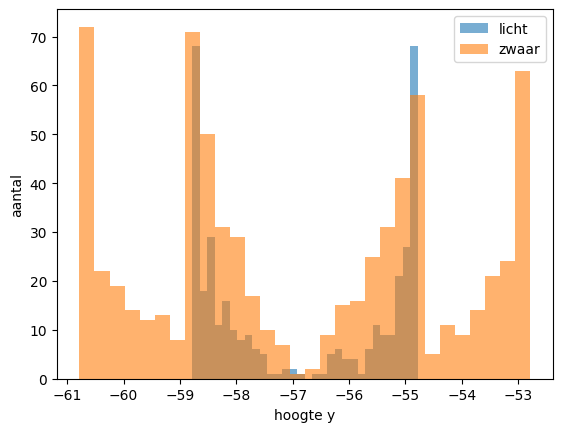

In [11]:
particles_with_light = []
Box_height = Box_length_0*18
Box_width = Box_length_0*9

def boxcollision(self):
    if abs(self.r[0]) + self.R > Box_width:
        self.v[0] *= -1
        self.r[0] = np.sign(self.r[0]) * (Box_width - self.R)

    if abs(self.r[1]) + self.R > Box_height:
        self.v[1] *= -1
        self.r[1] = np.sign(self.r[1]) * (Box_height - self.R)

for i in range(360):
    vx_light = np.random.uniform(-v_0,v_0)
    vy_light = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx_light**2)       
    particles.append(ParticleClass(m=1.0, v=[vx_light, vy_light], r=pos, R=.5, c='blue'))

for i in range(360):
    vx_light = np.random.uniform(-v_0,v_0)
    vy_light = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx_light**2)       
    particles.append(ParticleClass(m=0.2, v=[vx_light, vy_light], r=pos, R=.5, c='blue'))



g = -9.81   # artificieel groot, expres!

def update_position(self):
    self.v[1] += g * dt        # zwaartekracht
    self.r += self.v * dt


for step in range(N_steps):

    for p in particles:
        update_position(p)
        boxcollision(p)

    handle_collisions(particles)

y_light = []
y_heavy = []

for p in particles:
    if p.m < 0.5:
        y_light.append(p.r[1])
    else:
        y_heavy.append(p.r[1])

print("Gemiddelde hoogte lichte deeltjes:", np.mean(y_light))
print("Gemiddelde hoogte zware deeltjes:", np.mean(y_heavy))

plt.hist(y_light, bins=30, alpha=0.6, label="licht")
plt.hist(y_heavy, bins=30, alpha=0.6, label="zwaar")
plt.xlabel("hoogte y")
plt.ylabel("aantal")
plt.legend()
plt.show()












Gemiddelde hoogte lichte deeltjes: -62.01143550362651
Gemiddelde hoogte zware deeltjes: -64.57955584564809
Hoogte zware deeltje: -59.36867980503639


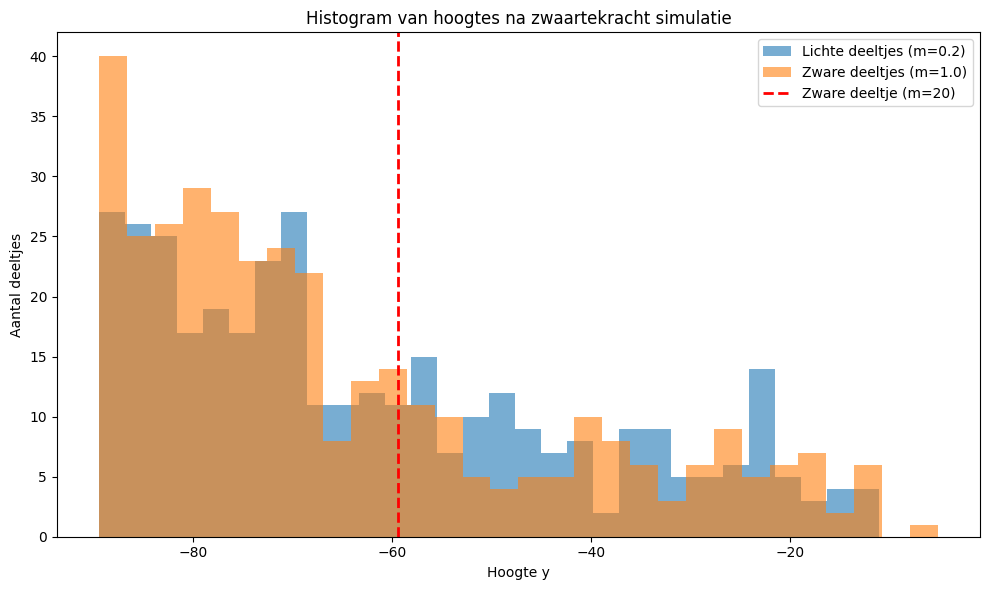

In [12]:
# Verbeterde simulatie van zwaartekracht op zware en lichtere deeltjes
# Fixes: genereer unieke startposities voor elke deeltje, verhoog g voor duidelijker effect, voeg zd toe aan particles lijst voor consistentie, en zorg ervoor dat deeltjes in de box blijven door boxcollision na botsingen te controleren

particles = []
Box_height = Box_length_0 * 18
Box_width = Box_length_0 * 9

def boxcollision(self):
    if abs(self.r[0]) + self.R > Box_width:
        self.v[0] *= -1
        self.r[0] = np.sign(self.r[0]) * (Box_width - self.R)
    if abs(self.r[1]) + self.R > Box_height:
        self.v[1] *= -1
        self.r[1] = np.sign(self.r[1]) * (Box_height - self.R)

# Verhoog g voor sneller effect
g = -50.0  # artificieel groot

def update_position(self):
    self.v[1] += g * dt
    self.r += self.v * dt

# Genereer zware deeltjes (m=1.0)
for i in range(360):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = np.array([Box_width * np.random.uniform(-1, 1), Box_height * np.random.uniform(-1, 1)])
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r=pos, R=.5, c='blue'))

# Genereer lichtere deeltjes (m=0.2)
for i in range(360):
    vx = np.random.uniform(-v_0, v_0)
    vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
    pos = np.array([Box_width * np.random.uniform(-1, 1), Box_height * np.random.uniform(-1, 1)])
    particles.append(ParticleClass(m=0.2, v=[vx, vy], r=pos, R=.5, c='green'))  # verander kleur voor onderscheid

# Voeg zware deeltje toe
vx = np.random.uniform(-v_0, v_0)
vy = np.random.choice([-1, 1]) * np.sqrt(v_0**2 - vx**2)
pos = np.array([Box_width * np.random.uniform(-1, 1), Box_height * np.random.uniform(-1, 1)])
zd = ParticleClass(m=20.0, v=[vx, vy], r=pos, R=.5, c='red')
particles.append(zd)

# Simulatie loop
for step in range(N_steps):
    for p in particles:
        update_position(p)
        boxcollision(p)
    handle_collisions(particles)
    # Controleer wandbotsingen opnieuw na onderlinge botsingen om te zorgen dat deeltjes in de box blijven
    for p in particles:
        boxcollision(p)

# Verzamel y-posities
y_light = []
y_heavy = []
y_zd = []

for p in particles:
    if p.m < 0.5:
        y_light.append(p.r[1])
    elif p.m > 10:  # zware deeltje
        y_zd.append(p.r[1])
    else:
        y_heavy.append(p.r[1])

print("Gemiddelde hoogte lichte deeltjes:", np.mean(y_light))
print("Gemiddelde hoogte zware deeltjes:", np.mean(y_heavy))
print("Hoogte zware deeltje:", y_zd[0] if y_zd else "N/A")

plt.figure(figsize=(10, 6))
plt.hist(y_light, bins=30, alpha=0.6, label="Lichte deeltjes (m=0.2)")
plt.hist(y_heavy, bins=30, alpha=0.6, label="Zware deeltjes (m=1.0)")
if y_zd:
    plt.axvline(y_zd[0], color='red', linestyle='--', linewidth=2, label="Zware deeltje (m=20)")
plt.xlabel("Hoogte y")
plt.ylabel("Aantal deeltjes")
plt.title("Histogram van hoogtes na zwaartekracht simulatie")
plt.legend()
plt.tight_layout()
plt.show()